In [22]:
%pip install plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
import plotly.express as px
sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.


In [23]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('usa_oilandgas_production.csv')

In [24]:
df = pd.read_csv('usa_oilandgas_production.csv')

In [25]:
df.head()

,Production Date,Land Class,Land Category,State,County,FIPS Code,Offshore Region,Commodity,Unit,Disposition Code,Disposition Description,Volume
0,1/1/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Alaska,Gas,Mcf,1,Sales-Royalty Due-MEASURED,0.0
1,1/1/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Gulf,Gas,Mcf,1,Sales-Royalty Due-MEASURED,14508756.0
2,1/1/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Pacific,Gas,Mcf,1,Sales-Royalty Due-MEASURED,1207520.0
3,1/1/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Gulf,Gas,Mcf,4,Sales-Royalty Due-Not Measured,487324.0
4,1/1/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Pacific,Gas,Mcf,4,Sales-Royalty Due-Not Measured,114808.0


In [26]:
df[df['State'] == 'TX']

,Production Date,Land Class,Land Category,State,County,FIPS Code,Offshore Region,Commodity,Unit,Disposition Code,Disposition Description,Volume
274,1/1/2015,Federal,Onshore,TX,Burleson,48051,Onshore,Gas,Mcf,1,Sales-Royalty Due-MEASURED,324.0
275,1/1/2015,Federal,Onshore,TX,Denton,48121,Onshore,Gas,Mcf,1,Sales-Royalty Due-MEASURED,34107.0
276,1/1/2015,Federal,Onshore,TX,Freestone,48161,Onshore,Gas,Mcf,1,Sales-Royalty Due-MEASURED,4846.0
277,1/1/2015,Federal,Onshore,TX,Galveston,48167,Onshore,Gas,Mcf,1,Sales-Royalty Due-MEASURED,4.0
278,1/1/2015,Federal,Onshore,TX,Grayson,48181,Onshore,Gas,Mcf,1,Sales-Royalty Due-MEASURED,1041.0
...,...,...,...,...,...,...,...,...,...,...,...,...
470369,1/5/2025,Federal,Onshore,TX,Galveston,48167,Onshore,Oil,bbl,42,Differences/Adjustments,0.0
470370,1/5/2025,Federal,Onshore,TX,Hill,48217,Onshore,Oil,bbl,42,Differences/Adjustments,0.0
470371,1/5/2025,Federal,Onshore,TX,Mcmullen,48311,Onshore,Oil,bbl,42,Differences/Adjustments,0.0
470372,1/5/2025,Federal,Onshore,TX,Zapata,48505,Onshore,Oil,bbl,42,Differences/Adjustments,0.0


In [27]:
country = ['Denton', 'Canada', 'Mexico', 'Brazil', 'Argentina', 'Colombia', 'Venezuela', 'Ecuador', 'Peru', 'Chile']
df[df['County'].isin(country)]

,Production Date,Land Class,Land Category,State,County,FIPS Code,Offshore Region,Commodity,Unit,Disposition Code,Disposition Description,Volume
275,1/1/2015,Federal,Onshore,TX,Denton,48121,Onshore,Gas,Mcf,1,Sales-Royalty Due-MEASURED,34107.0
730,1/1/2015,Federal,Onshore,TX,Denton,48121,Onshore,Gas,Mcf,11,Transferred to Facility,72989.0
1071,1/1/2015,Federal,Onshore,TX,Denton,48121,Onshore,Gas,Mcf,17,Water Injected/Transferred Off-L/A,0.0
1270,1/1/2015,Federal,Onshore,TX,Denton,48121,Onshore,Gas,Mcf,20,Used on L/A-Native Production Only,29.0
1665,1/1/2015,Federal,Onshore,TX,Denton,48121,Onshore,Gas,Mcf,27,Water Disposal-Other than Injected/Transferred,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
469766,1/5/2025,Federal,Onshore,TX,Denton,48121,Onshore,Oil,bbl,17,Water Injected/Transferred Off-L/A,0.0
469937,1/5/2025,Federal,Onshore,TX,Denton,48121,Onshore,Oil,bbl,20,Used on L/A-Native Production Only,0.0
470091,1/5/2025,Federal,Onshore,TX,Denton,48121,Onshore,Oil,bbl,25,Buy-Back Purchased for L/A Use,0.0
470261,1/5/2025,Federal,Onshore,TX,Denton,48121,Onshore,Oil,bbl,27,Water Disposal-Other than Injected/Transferred,0.0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470830 entries, 0 to 470829
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Production Date          470830 non-null  object 
 1   Land Class               470830 non-null  object 
 2   Land Category            470830 non-null  object 
 3   State                    470830 non-null  object 
 4   County                   470830 non-null  object 
 5   FIPS Code                470830 non-null  object 
 6   Offshore Region          470830 non-null  object 
 7   Commodity                470830 non-null  object 
 8   Unit                     470830 non-null  object 
 9   Disposition Code         470830 non-null  int64  
 10  Disposition Description  470830 non-null  object 
 11  Volume                   470076 non-null  float64
dtypes: float64(1), int64(1), object(10)
memory usage: 43.1+ MB


In [29]:
df['Production Date'] = pd.to_datetime(df['Production Date'])

In [30]:
trend = df.groupby('Production Date')['Volume'].mean()

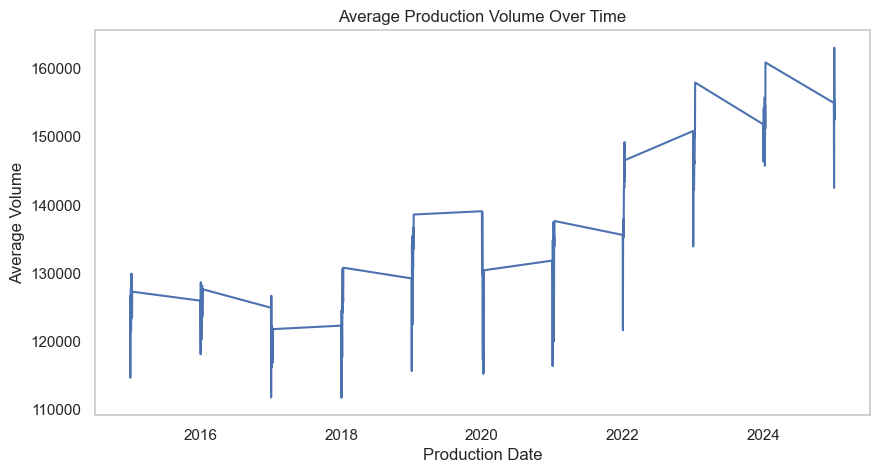

In [31]:
plt.figure(figsize=(10,5))
plt.plot(trend.index, trend.values)
plt.title('Average Production Volume Over Time')
plt.xlabel('Production Date')
plt.ylabel('Average Volume')
plt.grid(False)
plt.show()

In [32]:
avg_state = df.groupby('State')['Volume'].mean().sort_values(ascending=False)

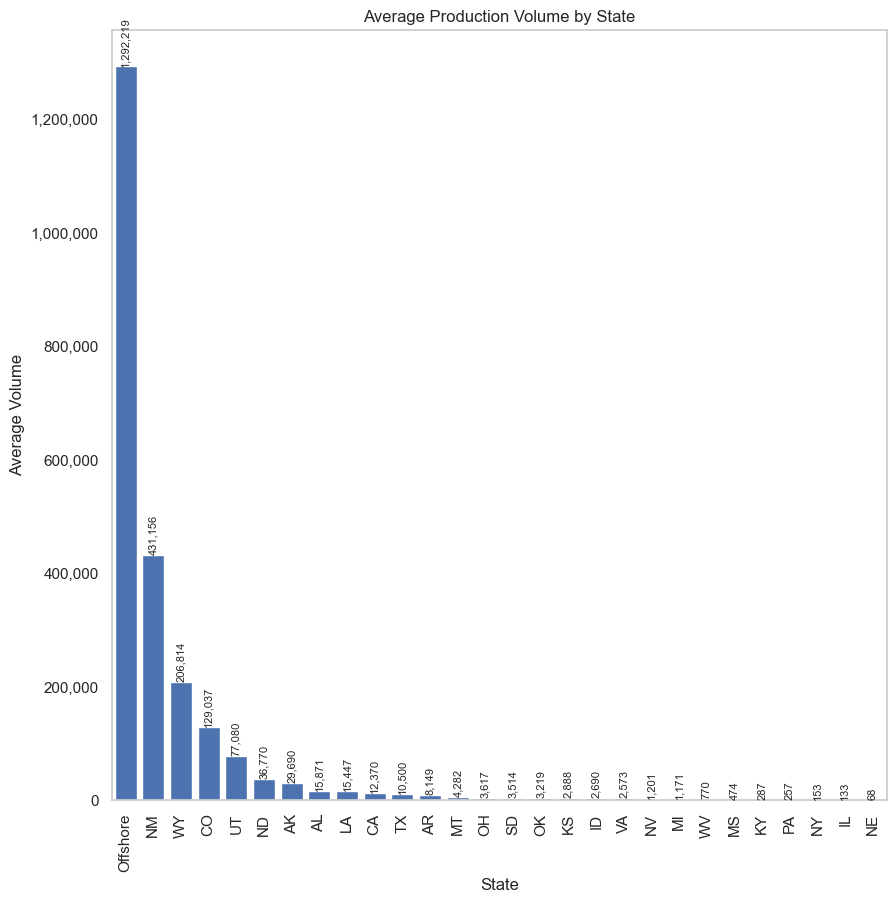

In [33]:
plt.figure(figsize=(10,10))
avg_state.plot(kind='bar')
plt.bar(avg_state.index, avg_state.values)
plt.title('Average Production Volume by State')
plt.xlabel('State')
plt.ylabel('Average Volume')
ax = plt.gca()  
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
for i, v in enumerate(avg_state.values):
    ax.text(i, v + 1000, f"{v:,.0f}", ha='center', va='bottom', fontsize=8, rotation=90)
plt.grid(False)
plt.show()  

In [34]:
commodity_share = df.groupby('Commodity')['Volume'].sum()

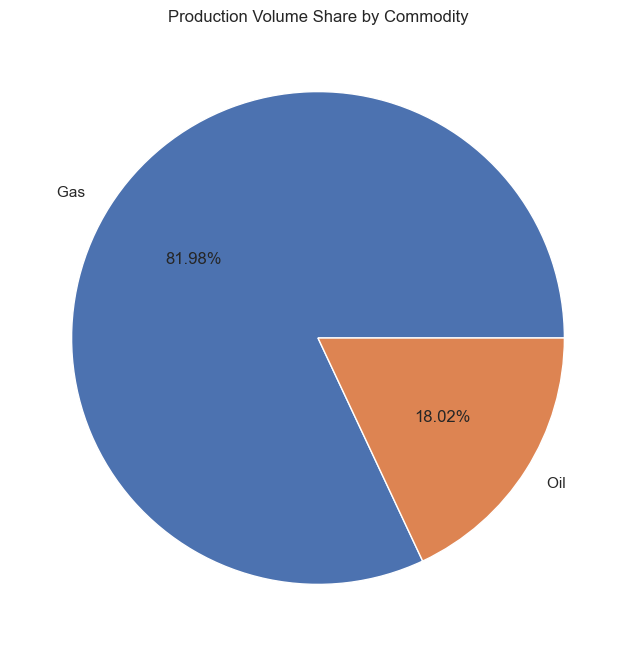

In [35]:
plt.figure(figsize=(8, 8))
commodity_share.plot(kind='pie', autopct='%.2f%%')
plt.title('Production Volume Share by Commodity')
plt.ylabel('')
plt.show()

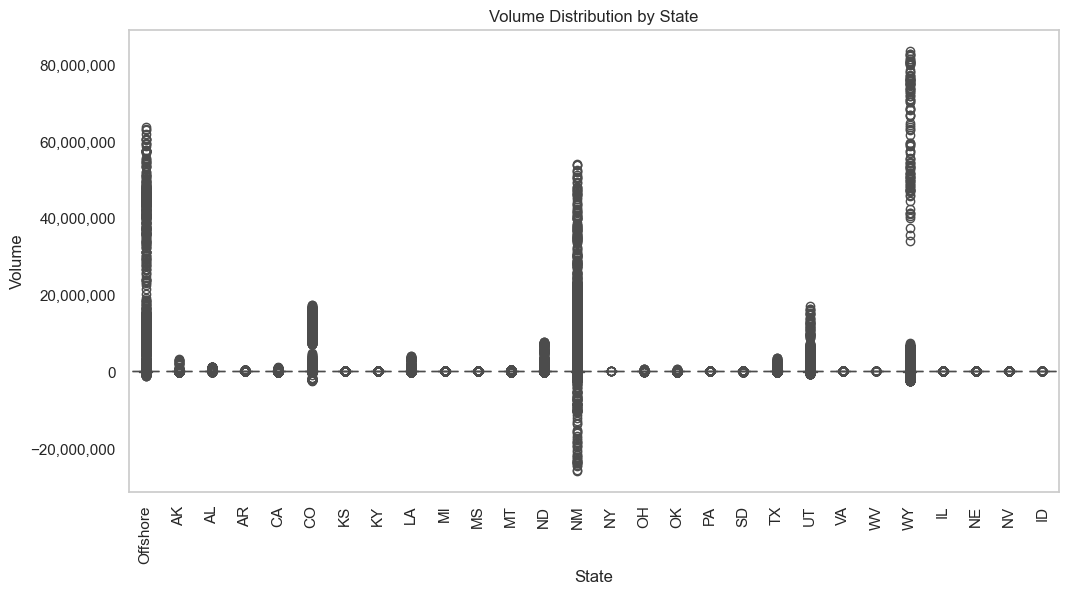

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='State', y='Volume', data=df)
plt.title('Volume Distribution by State')
plt.xlabel('State')
plt.ylabel('Volume')
ax = plt.gca()  
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=90)
plt.grid(False)
plt.show()

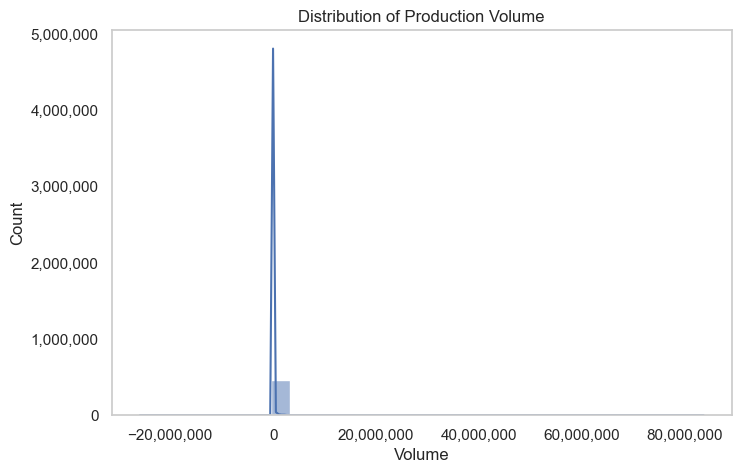

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Volume'].dropna(), kde=True, bins=30)
plt.title('Distribution of Production Volume')
plt.xlabel('Volume')
plt.ylabel('Count')
ax = plt.gca()   
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) 
plt.grid(False)
plt.show()


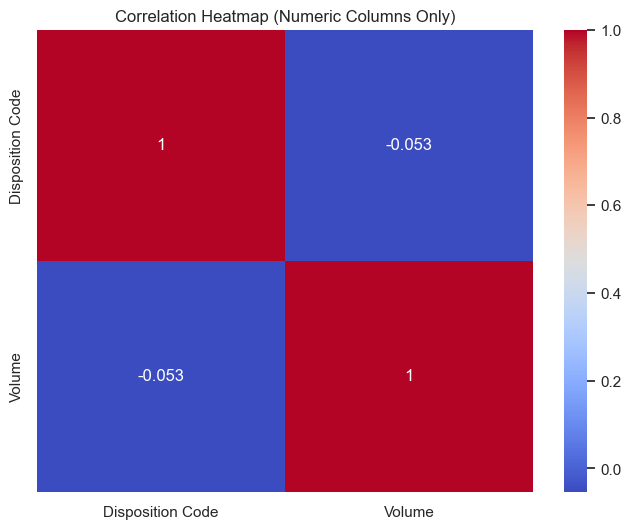

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()


In [ ]:
fig = px.line(df, x='Production Date', y='Volume', color='State',
              title='Interactive Production Trend by State')
fig.show(renderer='browser')